In [1]:
import torch

import numpy as np

from sbi.analysis import pairplot
from sbi.inference import NPE,NLE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
from torch.distributions import Normal, Independent,InverseGamma

In [2]:
num_dim = 2  # Here, num_dim = 2 indicates we have two parameters: μ and σ

def simulator(theta, n=100):
    # theta[0] is μ, theta[1] is σ
    mu, sigma = theta[0], theta[1]
    return mu + np.sqrt(sigma) * torch.randn(n)  # Generate n observations

prior = [
    Normal(torch.tensor([0.0]), torch.tensor([1.0])), 
    InverseGamma(torch.tensor([2.0]), torch.tensor([1.0]))
]


In [3]:
prior, num_parameters, prior_returns_numpy = process_prior(prior)
# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(simulator, prior, prior_returns_numpy)
# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)


/var/folders/xh/6yy1qtv504b1yv27rltr5cdc0000gn/T/ipykernel_57943/3563422826.py:1: UserWarning: Prior was provided as a sequence of 2 priors. They will be interpreted as independent of each other and matched in order to the components of the parameter.
  prior, num_parameters, prior_returns_numpy = process_prior(prior)
/var/folders/xh/6yy1qtv504b1yv27rltr5cdc0000gn/T/ipykernel_57943/395610175.py:6: RuntimeWarning: invalid value encountered in sqrt
  return mu + np.sqrt(sigma) * torch.randn(n)  # Generate n observations


In [4]:
inference = NLE(prior=prior)

# Generate simulation data
num_simulations = 500
theta = prior.sample((num_simulations,))
x = simulator(theta)

# Print and check shapes
print("theta.shape", theta.shape)
print("x.shape", x.shape)


theta.shape torch.Size([500, 2])
x.shape torch.Size([500, 100])


In [5]:
inference = inference.append_simulations(theta, x)
density_estimator = inference.train()

 Neural network successfully converged after 207 epochs.

In [6]:
posterior = inference.build_posterior(density_estimator)
theta_true = torch.tensor([[0.4,0.7]]) 
x_obs = simulator(theta_true)
samples = posterior.sample((10000,), x=x_obs)

/opt/anaconda3/envs/SBI_project/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:115: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

In [7]:
import numpy as np

# Prior parameters
mu_0 = 0
sigma_0_sq = 1  # Prior variance
alpha_0 = 2
beta_0 = 1  # Prior scale parameter

# Data preparation
Z = x_obs.numpy()  # If PyTorch tensor, convert to NumPy array
Z_flat = Z.flatten()  # Flatten to a one-dimensional array

# Sample mean and sample size
Y_mean = np.mean(Z_flat)  # Sample mean
n = Z.size  # Sample size

# Calculate total sample variance
variance = np.sum((Z_flat - Y_mean) ** 2)  # Total variance

kappa_0 = 1
kappa_n = kappa_0 + n

# Posterior parameter calculations
# Posterior for sigma^2
alpha_poster = alpha_0 + n / 2
beta_poster = beta_0 + 0.5 * variance + kappa_0 * n * (Y_mean - mu_0) ** 2 / (2 * kappa_n)

# Posterior for mu
sigma_poster_sq = sigma_0_sq / (kappa_0 + n)  # Posterior variance
mu_poster = (kappa_0 * mu_0 + n * Y_mean) / kappa_n  # Posterior mean

# Output results
print("Posterior alpha:", alpha_poster)
print("Posterior beta:", beta_poster)
print("Posterior mu (mean):", mu_poster)
print("Posterior sigma^2 (variance):", sigma_poster_sq)


Posterior alpha: 52.0
Posterior beta: 27.647745336262634
Posterior mu (mean): 0.37410993977348406
Posterior sigma^2 (variance): 0.009900990099009901


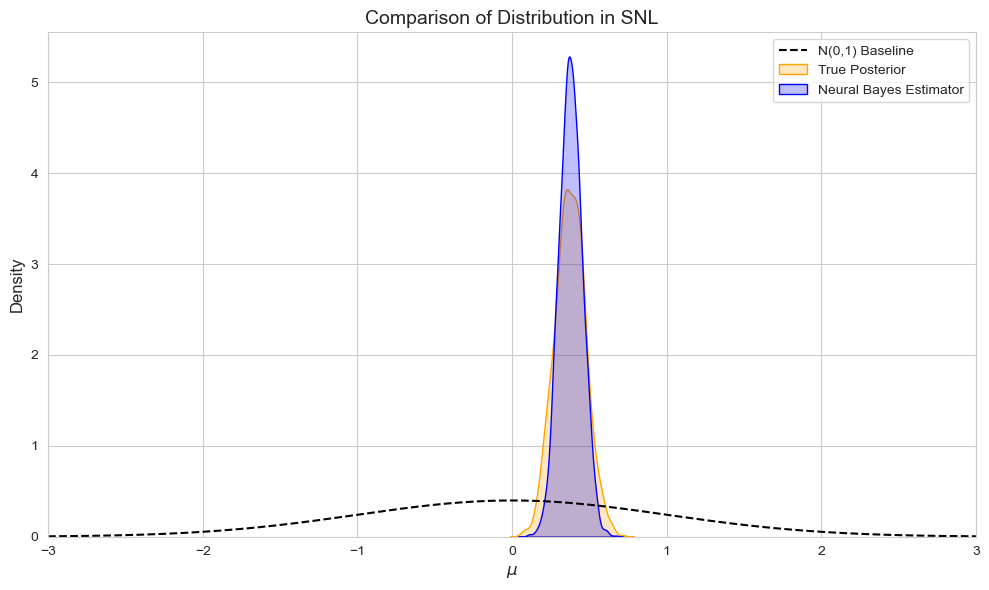

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

mu_samples = samples[:, 0].numpy()  # Extract the first dimension (mu) from the samples
theta_true = theta_true.numpy() if torch.is_tensor(theta_true) else theta_true
num_samples = 1000  # Number of samples

# Set parameters for the Prior distribution
mu_prior = 0  # Mean
sigma_prior = 1  # Standard deviation

# Generate N(0,1) density curve
x = np.linspace(-3, 3, 1000)  # Set x-axis range
y = stats.norm.pdf(x, loc=mu_prior, scale=sigma_prior)  # Compute N(0,1) density

# Plot N(0,1) curve on the same figure
plt.plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")

sigma_poster = np.sqrt(sigma_poster_sq)

# Generate samples from the Posterior distribution
posterior_samples_mu = np.random.normal(loc=mu_poster, scale=sigma_poster, size=num_samples)

# Plot the KDE for the Posterior samples
sns.kdeplot(posterior_samples_mu,label="True Posterior", fill=True, color="orange")

# Plot the KDE for the Posterior samples using sampled data
sns.kdeplot(mu_samples, fill=True, label=r"Neural Bayes Estimator", color="blue")

# If needed, plot the true theta value
theta_true_value = theta_true[0, 0].item()

ax.set_title("Comparison of Distribution in SNL", fontsize=14)
ax.set_xlabel(r"$\mu$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True)

# Set x-axis range
ax.set_xlim(-3, 3)

# Show the plot
plt.tight_layout()
plt.show()


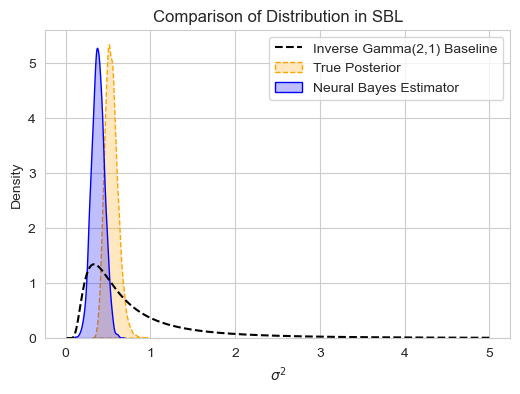

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assume alpha_poster and beta_poster are already defined
alpha_prior = 2.0  # Inverse Gamma shape parameter α
beta_prior = 1.0   # Inverse Gamma rate parameter β

# Create the plot
plt.figure(figsize=(6, 4))

# Generate Inverse Gamma(2,1) density curve
x = np.linspace(0.01, 5, 1000)  # Inverse Gamma domain x > 0, avoid division by zero
y = stats.invgamma.pdf(x, a=alpha_prior, scale=beta_prior)  # α=2, β=1

# Plot Inverse Gamma(2,1) as baseline
plt.plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

# Sample from the Posterior Inverse Gamma distribution
gamma_samples = np.random.gamma(shape=alpha_poster, scale=1 / beta_poster, size=10000)
inverse_gamma_samples = 1 / gamma_samples
sns.kdeplot(inverse_gamma_samples, label="True Posterior", fill=True, color="orange", linestyle="--")

# Extract the first dimension of samples (e.g., μ)
sigma_samples = samples[:, 0].numpy()
sns.kdeplot(sigma_samples, label="Neural Bayes Estimator", fill=True, color="blue")

# Labels and legend
plt.xlabel(r"$\sigma^2$")
plt.ylabel("Density")
plt.title("Comparison of Distribution in SBL")
plt.legend()
plt.show()


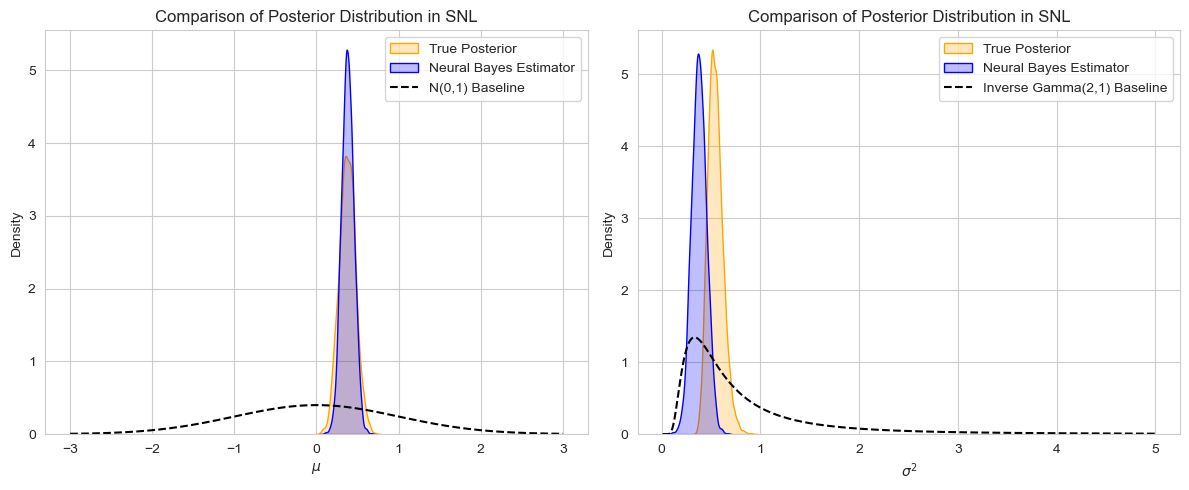

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ======== Create subplots ========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Arrange two plots horizontally

# ======== Left plot: Comparison of True vs. Neural Posterior with N(0,1) ========
# Plot true posterior
sns.kdeplot(posterior_samples_mu, label="True Posterior", fill=True, color="orange", ax=axes[0])

# Plot inferred posterior
sns.kdeplot(mu_samples, label="Neural Bayes Estimator", fill=True, color="blue", ax=axes[0])

# Generate density curve for N(0,1)
x = np.linspace(-3, 3, 1000)
y = stats.norm.pdf(x, loc=0, scale=1)
axes[0].plot(x, y, label="N(0,1) Baseline", color="black", linestyle="--")

# Axis labels and legend
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"Comparison of Posterior Distribution in SNL")
axes[0].legend()


# ======== Right plot: Comparison of True vs. Neural Posterior with Inverse Gamma ========
# Plot true posterior
sns.kdeplot(inverse_gamma_samples, label="True Posterior", fill=True, color="orange", ax=axes[1])

# Plot inferred posterior
sns.kdeplot(sigma_samples, label="Neural Bayes Estimator", fill=True, color="blue", ax=axes[1])

# Generate density curve for Inverse Gamma(2,1)
x = np.linspace(0.01, 5, 1000)
y = stats.invgamma.pdf(x, a=2, scale=1)
axes[1].plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

# Axis labels and legend
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Comparison of Posterior Distribution in SNL")
axes[1].legend()


# ======== Adjust layout ========
plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, linregress
from torch.distributions import Normal, InverseGamma

mu_prior = Normal(torch.tensor(0.0), torch.tensor(1.0))           # μ ~ Normal(0, 1)
sigma2_prior = InverseGamma(torch.tensor(2.0), torch.tensor(1.0)) # σ² ~ InverseGamma(2, 1)

# Sample from the prior distribution
num_samples = 50
mu_values = mu_prior.sample((num_samples,))          # Directly sample from Normal
sigma2_values = sigma2_prior.sample((num_samples,))

posterior_mu_means = []
posterior_mu_stds = []
posterior_sigma2_means = []
posterior_sigma2_stds = []

mu_ground_truth = []
sigma2_ground_truth = []

# Perform inference for each (mu, sigma2) pair
for mu, sigma2 in zip(mu_values, sigma2_values):
    theta_true = torch.tensor([[mu.item(), sigma2.item()]])  # (1, 2)
    x_obs = simulator(theta_true)
    samples = posterior.sample((10000,), x=x_obs)
    
    mu_samples = samples[:, 0].numpy()       # Posterior samples for μ
    sigma2_samples = samples[:, 1].numpy()   # Posterior samples for σ²

    posterior_mu_means.append(np.mean(mu_samples))
    posterior_mu_stds.append(np.std(mu_samples))
    posterior_sigma2_means.append(np.mean(sigma2_samples))
    posterior_sigma2_stds.append(np.std(sigma2_samples))

    mu_ground_truth.append(mu.item())
    sigma2_ground_truth.append(sigma2.item())

# Convert to NumPy arrays
mu_ground_truth = np.array(mu_ground_truth)
sigma2_ground_truth = np.array(sigma2_ground_truth)

mu_estimated = np.array(posterior_mu_means)
sigma2_estimated = np.array(posterior_sigma2_means)

mu_error_std = np.array(posterior_mu_stds)
sigma2_error_std = np.array(posterior_sigma2_stds)


Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

...

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/15000 [00:00<?, ?it/s]

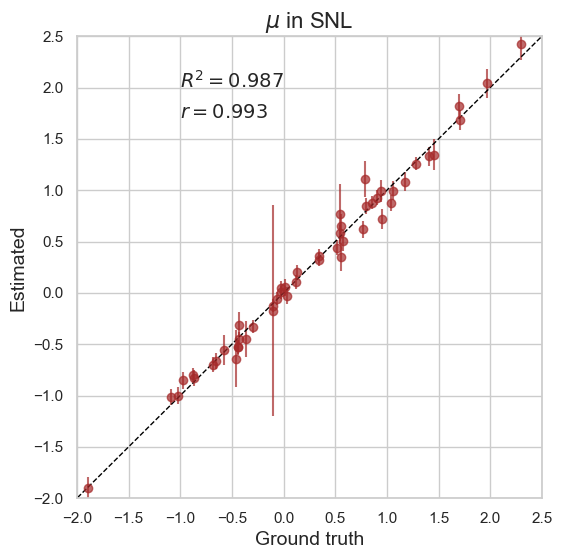

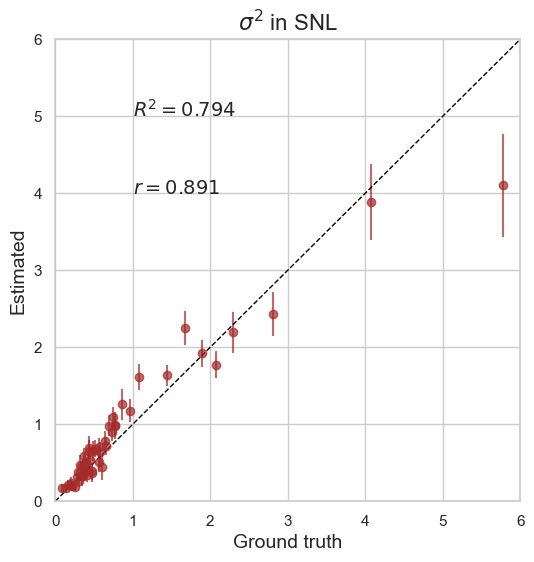

In [12]:
# ========== Recovery Line ==========
# ---- Recovery Line for μ ----
slope, intercept, r_value, p_value, std_err = linregress(mu_ground_truth, mu_estimated)
r_squared = r_value ** 2
pearson_corr, _ = pearsonr(mu_ground_truth, mu_estimated)

plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")

plt.errorbar(mu_ground_truth, mu_estimated, yerr=mu_error_std, fmt='o', color='brown', alpha=0.7)
plt.plot([-3, 3], [-3, 3], '--', color='black', linewidth=1)

plt.text(-1, 2, rf"$R^2 = {r_squared:.3f}$", fontsize=14, fontstyle='italic')
plt.text(-1, 1.7, rf"$r = {pearson_corr:.3f}$", fontsize=14, fontstyle='italic')

plt.xlabel("Ground truth", fontsize=14) 
plt.ylabel("Estimated", fontsize=14)   
plt.title(r"$\mu$ in SNL", fontsize=16) 
plt.xlim(-2, 2.5)
plt.ylim(-2, 2.5)
plt.show()


# ---- Recovery Line for σ² ----
slope, intercept, r_value, p_value, std_err = linregress(sigma2_ground_truth, sigma2_estimated)
r_squared = r_value ** 2
pearson_corr, _ = pearsonr(sigma2_ground_truth, sigma2_estimated)

plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")

plt.errorbar(sigma2_ground_truth, sigma2_estimated, yerr=sigma2_error_std, fmt='o', color='brown', alpha=0.7)
plt.plot([0, 10], [0, 10], '--', color='black', linewidth=1)

plt.text(1, 5, rf"$R^2 = {r_squared:.3f}$", fontsize=14, fontstyle='italic') 
plt.text(1, 4, rf"$r = {pearson_corr:.3f}$", fontsize=14, fontstyle='italic')

plt.xlabel("Ground truth", fontsize=14)
plt.ylabel("Estimated", fontsize=14) 
plt.title(r"$\sigma^2$ in SNL", fontsize=16) 
plt.xlim(0, 6) 
plt.ylim(0, 6) 
plt.show()



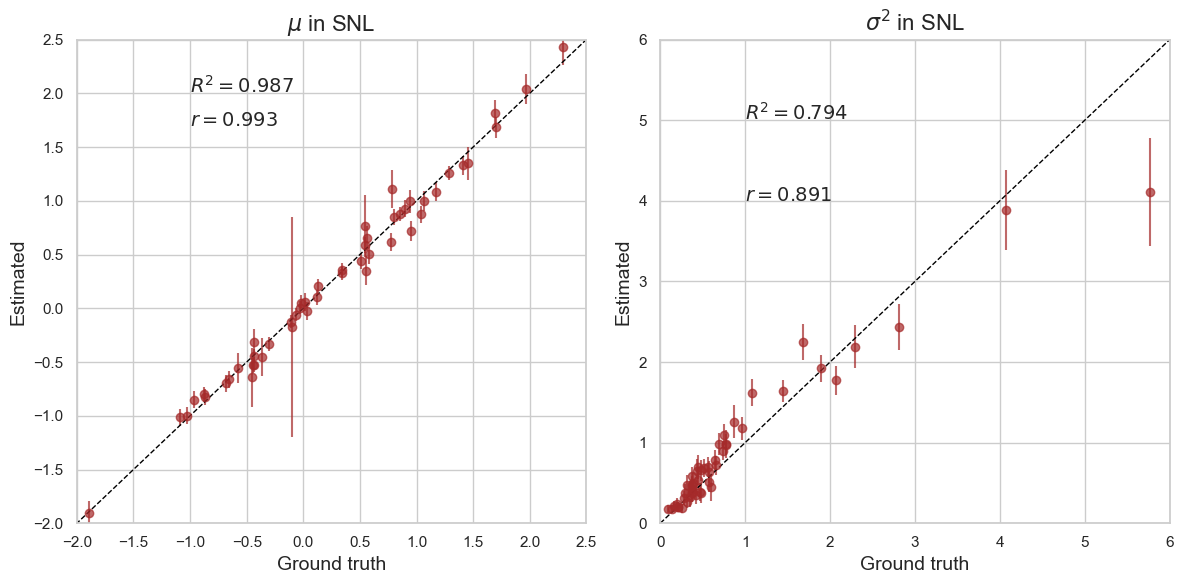

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, pearsonr

# ---- Recovery Line for μ ----
slope, intercept, r_value, p_value, std_err = linregress(mu_ground_truth, mu_estimated)
r_squared_mu = r_value ** 2
pearson_corr_mu, _ = pearsonr(mu_ground_truth, mu_estimated)

# ---- Recovery Line for σ² ----
slope, intercept, r_value, p_value, std_err = linregress(sigma2_ground_truth, sigma2_estimated)
r_squared_sigma2 = r_value ** 2
pearson_corr_sigma2, _ = pearsonr(sigma2_ground_truth, sigma2_estimated)

# ---- Combined Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set(style="whitegrid")

# ---- Left: μ ----
axes[0].errorbar(mu_ground_truth, mu_estimated, yerr=mu_error_std, fmt='o', color='brown', alpha=0.7)
axes[0].plot([-3, 3], [-3, 3], '--', color='black', linewidth=1)

axes[0].text(-1, 2, rf"$R^2 = {r_squared_mu:.3f}$", fontsize=14, fontstyle='italic')
axes[0].text(-1, 1.7, rf"$r = {pearson_corr_mu:.3f}$", fontsize=14, fontstyle='italic')

axes[0].set_xlabel("Ground truth", fontsize=14)
axes[0].set_ylabel("Estimated", fontsize=14)
axes[0].set_title(r"$\mu$ in SNL", fontsize=16)
axes[0].set_xlim(-2, 2.5)
axes[0].set_ylim(-2, 2.5)

# ---- Right: σ² ----
axes[1].errorbar(sigma2_ground_truth, sigma2_estimated, yerr=sigma2_error_std, fmt='o', color='brown', alpha=0.7)
axes[1].plot([0, 10], [0, 10], '--', color='black', linewidth=1)

axes[1].text(1, 5, rf"$R^2 = {r_squared_sigma2:.3f}$", fontsize=14, fontstyle='italic')
axes[1].text(1, 4, rf"$r = {pearson_corr_sigma2:.3f}$", fontsize=14, fontstyle='italic')

axes[1].set_xlabel("Ground truth", fontsize=14)
axes[1].set_ylabel("Estimated", fontsize=14)
axes[1].set_title(r"$\sigma^2$ in SNL", fontsize=16)
axes[1].set_xlim(0, 6)
axes[1].set_ylim(0, 6)

plt.tight_layout()
plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import CubicSpline


def plot_rank_ecdf_final(
    estimated,
    ground_truth,
    difference=True,
    rank_ecdf_color="#a34f4f",
    fill_color="grey",
    figsize=(6, 6),
    title="Rank ECDF for μ",
    band_factor=1.68
):
    # ---- Fractional Rank ----
    ranks = np.sum(estimated[:, None] >= ground_truth, axis=1) / len(ground_truth)
    ranks = np.clip(ranks, 1e-8, 1 - 1e-8)

    # ---- ECDF Calculation ----
    ecdf_single = np.sort(ranks)
    x_values = np.linspace(0, 1, 100)
    yy = np.arange(1, len(ecdf_single) + 1) / len(ecdf_single)
    yy_interp = np.interp(x_values, ecdf_single, yy)

    cs = CubicSpline(x_values, yy_interp)
    x_smooth = np.linspace(0, 1, 300)
    yy_smooth = cs(x_smooth)

    # ---- ECDF Difference ----
    if difference:
        yy_smooth -= x_smooth
        ylabel = "ECDF difference"
    else:
        ylabel = "ECDF"

    # ---- Simultaneous ECDF Bands ----
    n = len(ranks)
    z = np.linspace(0, 1, 300)
    c = band_factor / np.sqrt(n)

    L = z - c * np.sqrt(z * (1 - z))
    H = z + c * np.sqrt(z * (1 - z))

    if difference:
        L -= z
        H -= z

    y_min = np.min(L)
    y_max = np.max(H)

    # ---- Plot ----
    plt.figure(figsize=figsize)
    sns.set(style="whitegrid")

    plt.plot(x_smooth, yy_smooth, color=rank_ecdf_color, label="Rank ECDF", linewidth=2, antialiased=True)

    plt.fill_between(z, L, H, color=fill_color, alpha=0.35, label="95% Confidence Bands")

    plt.xlabel("Fractional rank statistic", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)
    plt.xlim(0, 1)
    plt.ylim(y_min, y_max) 
    plt.legend(fontsize=10)
    plt.grid(True, linewidth=0.7, alpha=0.6)
    plt.show()


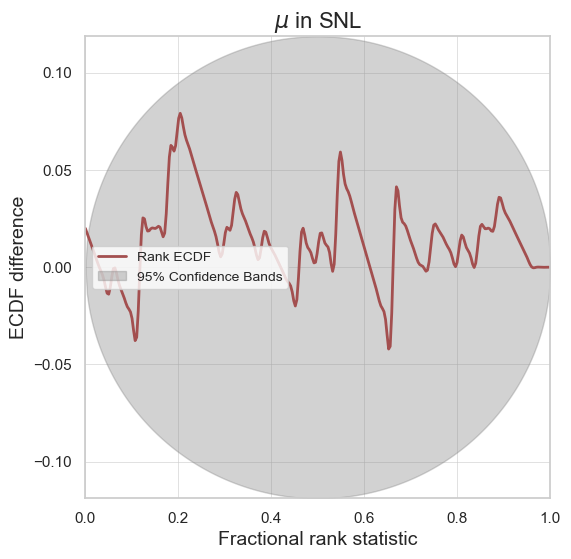

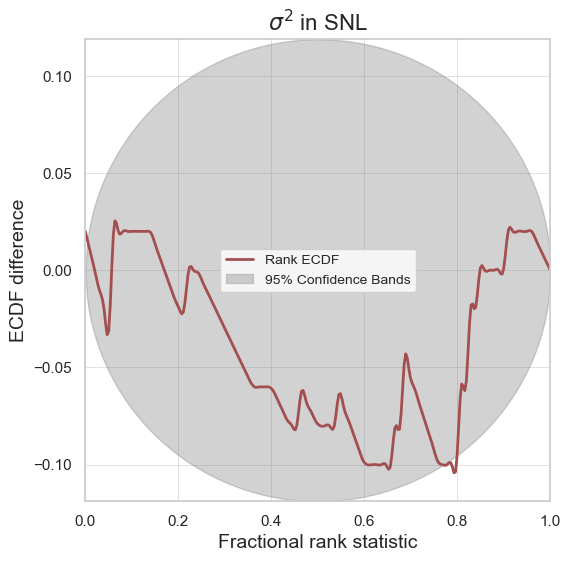

In [15]:


plot_rank_ecdf_final(mu_estimated, mu_ground_truth, difference=True, 
                     title=r"$\mu$ in SNL")

plot_rank_ecdf_final(sigma2_estimated, sigma2_ground_truth, difference=True, 
                     title=r"$\sigma^2$ in SNL")
